# Bridge: outreach → money → outcomes (Hiraya Haven)

**Pipeline:** Join outreach activity, donation totals, and aggregate outcome metrics by month to explore relationships and build a simple forecast.

**Data:** `social_media_posts`, `donations`, `safehouse_monthly_metrics`, `public_impact_snapshots` from `../Data/hiraya.db`.

**Explanatory:** associations between outreach/donations and aggregate outcome metrics.

**Predictive:** forecast next month donation total (or incident load) using outreach lag features.

> Caution: ecological fallacy — these are aggregate relationships, not individual causal effects.

## 1. Problem framing

Hiraya Haven wants to connect outreach strategy to fundraising and (aggregate) outcomes for planning and communication.

- **Explanatory goal:** explore associations between outreach volume/engagement, donation totals, and aggregate safehouse outcomes.
- **Predictive goal:** forecast next-month donation totals from lagged outreach signals.

**Success metrics:** MAE for forecasting; clear explanation of limits (aggregate ≠ causal).

## 2. Data acquisition, preparation & exploration

We aggregate `social_media_posts`, `donations`, and `safehouse_monthly_metrics` to monthly totals and join on month.

## 3. Modeling & feature selection

Ridge regression with scaled features on lagged outreach + lagged donations.

## 4. Evaluation & interpretation

Evaluate with a time split. Interpret forecast errors in planning terms (staffing and campaign timing).

## 5. Causal and relationship analysis

Ecological fallacy risk: these are aggregate patterns with confounding by seasonality and external events.

## 6. Deployment notes

Deploy as a monthly funnel dashboard + planning forecast; use for monitoring and hypothesis generation.

In [1]:
# ============================================================================
# Outreach–money–outcomes bridge — Monthly aggregates across three domains
# ============================================================================
# Notebook code cell overview — see inline comments below.
#
# Social posts → outreach metrics (volume, impressions, referrals).
# Donations → PHP totals per month.
# Safehouse monthly metrics + public impact snapshots → operational and outcome proxies.
# Outer merges build a wide monthly table for correlation / regression (next cells).
#
from __future__ import annotations

import sqlite3
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid", context="notebook")

ROOT = Path("..").resolve()
DB_PATH = ROOT / "Data" / "hiraya.db"

with sqlite3.connect(DB_PATH) as conn:
    posts = pd.read_sql_query('SELECT * FROM "social_media_posts"', conn)
    donations = pd.read_sql_query('SELECT * FROM "donations"', conn)
    metrics = pd.read_sql_query('SELECT * FROM "safehouse_monthly_metrics"', conn)
    impact = pd.read_sql_query('SELECT * FROM "public_impact_snapshots"', conn)

posts["created_at"] = pd.to_datetime(posts["created_at"], errors="coerce")
donations["donation_date"] = pd.to_datetime(donations["donation_date"], errors="coerce")
metrics["month_start"] = pd.to_datetime(metrics["month_start"], errors="coerce")
impact["snapshot_date"] = pd.to_datetime(impact["snapshot_date"], errors="coerce")

# Outreach monthly aggregates
posts["month"] = posts["created_at"].dt.to_period("M").dt.to_timestamp()
outreach = posts.groupby("month", as_index=False).agg(
    posts_n=("post_id", "count"),
    impressions=("impressions", "sum"),
    reach=("reach", "sum"),
    likes=("likes", "sum"),
    comments=("comments", "sum"),
    shares=("shares", "sum"),
    click_throughs=("click_throughs", "sum"),
    donation_referrals=("donation_referrals", "sum"),
)

# Donation monthly aggregates
val = donations["amount"].fillna(donations["estimated_value"]).fillna(0.0)
donations["value_php"] = val
donations["month"] = donations["donation_date"].dt.to_period("M").dt.to_timestamp()
don_month = donations.groupby("month", as_index=False).agg(
    donation_total_php=("value_php", "sum"),
    donation_n=("donation_id", "count"),
)

# Outcome monthly aggregates (safehouse metrics -> national aggregate)
outcome = metrics.groupby("month_start", as_index=False).agg(
    incidents=("incident_count", "sum"),
    avg_edu_progress=("avg_education_progress", "mean"),
    avg_health=("avg_health_score", "mean"),
    active_residents=("active_residents", "sum"),
).rename(columns={"month_start": "month"})

bridge = outreach.merge(don_month, on="month", how="outer").merge(outcome, on="month", how="outer").sort_values("month")
bridge = bridge.fillna(0)

bridge.tail()

,month,posts_n,impressions,reach,likes,comments,shares,click_throughs,donation_referrals,donation_total_php,donation_n,incidents,avg_edu_progress,avg_health,active_residents
45,2026-10-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,60
46,2026-11-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,60
47,2026-12-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,60
48,2027-01-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,60
49,2027-02-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,60


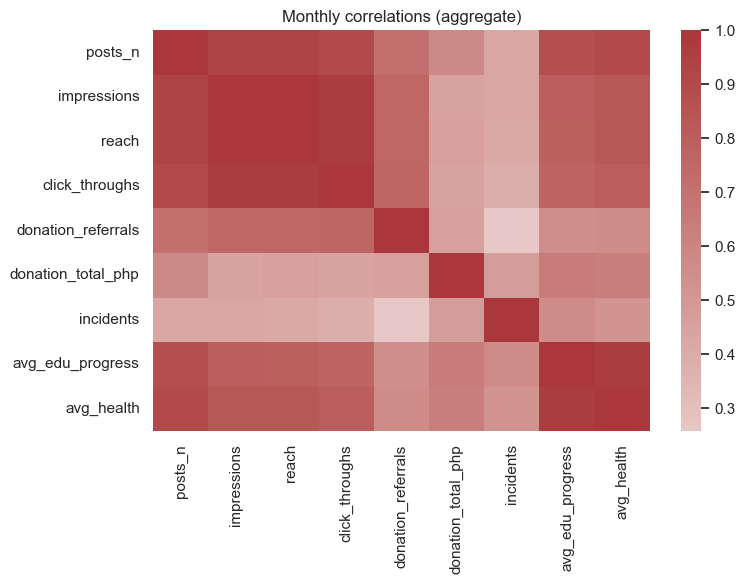

In [2]:
# ============================================================================
# Correlation heatmap across monthly metrics
# ============================================================================
# Notebook code cell overview — see inline comments below.
#
# Visualizes linear association — not causation. Good for hypothesis generation for leadership.
#
# Explanatory exploration: correlations at the monthly level

corr_cols = [
    "posts_n",
    "impressions",
    "reach",
    "click_throughs",
    "donation_referrals",
    "donation_total_php",
    "incidents",
    "avg_edu_progress",
    "avg_health",
]

corr = bridge[corr_cols].corr(numeric_only=True)
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=False, cmap="vlag", center=0)
plt.title("Monthly correlations (aggregate)")
plt.tight_layout()
plt.show()

In [3]:
# ============================================================================
# Predict next month's donation total from lags (outreach + past giving)
# ============================================================================
# Notebook code cell overview — see inline comments below.
#
# Ridge on scaled features; chronological 75/25 split within the modeling frame.
# This pattern maps directly to a live 'bridge' API endpoint (see SITE_INTEGRATION_PLAN.md).
#
# Predictive: forecast next month donation_total_php from outreach lags

df = bridge.sort_values("month").copy()
df["donation_next"] = df["donation_total_php"].shift(-1)

df["posts_lag1"] = df["posts_n"].shift(1)
df["clicks_lag1"] = df["click_throughs"].shift(1)
df["reach_lag1"] = df["reach"].shift(1)
df["don_total_lag1"] = df["donation_total_php"].shift(1)

train = df.dropna(subset=["donation_next", "don_total_lag1"]).copy()

X = train[["don_total_lag1", "posts_lag1", "clicks_lag1", "reach_lag1"]].fillna(0)
y = train["donation_next"]

cut = int(0.75 * len(train))
X_train, X_test = X.iloc[:cut], X.iloc[cut:]
y_train, y_test = y.iloc[:cut], y.iloc[cut:]

model = Pipeline([("scaler", StandardScaler()), ("ridge", Ridge(alpha=1.0))])
model.fit(X_train, y_train)
pred = model.predict(X_test)
print("MAE:", round(mean_absolute_error(y_test, pred), 2))

pd.DataFrame({"month": train["month"].iloc[cut:], "y_true": y_test.values, "y_pred": pred})

MAE: 10973.5


,month,y_true,y_pred
37,2026-02-01,342.96,7004.756698
38,2026-03-01,0.00,9961.321753
39,2026-04-01,0.00,11510.711211
40,2026-05-01,0.00,11505.354103
41,2026-06-01,0.00,11505.354103
42,2026-07-01,0.00,11505.354103
43,2026-08-01,0.00,11505.354103
44,2026-09-01,0.00,11505.354103
45,2026-10-01,0.00,11505.354103
46,2026-11-01,0.00,11505.354103


## Causal and relationship analysis

This pipeline is intentionally **aggregate**. Relationships can be misleading:

- A month with more posts and more donations does not mean the posts *caused* donations.
- External events (holidays, crises, news cycles) can drive both outreach and giving.

Use this as a narrative and monitoring tool: it helps Hiraya Haven ask better questions and decide what additional instrumentation is needed.

## Deployment notes

- Add a monthly “funnel” dashboard:
  - outreach volume → clicks → referred donations → total donations
  - overlay safehouse outcomes (incident totals, average progress)
- Use forecasts for staffing and fundraising planning, not for causal claims.